In [374]:
import numpy as np
import pandas as pd

In [375]:
df = pd.read_csv('dataset.csv')

In [378]:
df.head()

,File Count,Description_Length,Subdirectory
0,10,5,tumor
1,20,10,tumor
2,30,15,no_tumor
3,40,20,no_tumor
4,50,25,tumor


In [377]:
data = {
    'File Count': [10, 20, 30, 40, 50, 60],
    'Description_Length': [5, 10, 15, 20, 25, 30],
    'Subdirectory': ['tumor', 'tumor', 'no_tumor', 'no_tumor', 'tumor', 'no_tumor']
}
df = pd.DataFrame(data)

In [379]:
# Numerical ke liye:
df = df.fillna(df.mean(numeric_only=True))

# Sab kuch ek default value se:
df = df.fillna(0)  # caution: categorical values ke liye yeh galat ho sakta hai


In [380]:
df.isnull().sum()

,0
File Count,0
Description_Length,0
Subdirectory,0


In [381]:
df.sample()

,File Count,Description_Length,Subdirectory
4,50,25,tumor


In [382]:
df.shape

(6, 3)

In [383]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   File Count          6 non-null      int64 
 1   Description_Length  6 non-null      int64 
 2   Subdirectory        6 non-null      object
dtypes: int64(2), object(1)
memory usage: 276.0+ bytes


In [384]:
df.describe()

,File Count,Description_Length
count,6.000000,6.000000
mean,35.000000,17.500000
std,18.708287,9.354143
min,10.000000,5.000000
25%,22.500000,11.250000
50%,35.000000,17.500000
75%,47.500000,23.750000
max,60.000000,30.000000


In [385]:
df.duplicated().sum()

np.int64(0)

In [386]:
import seaborn as sns
import matplotlib.pyplot as plt

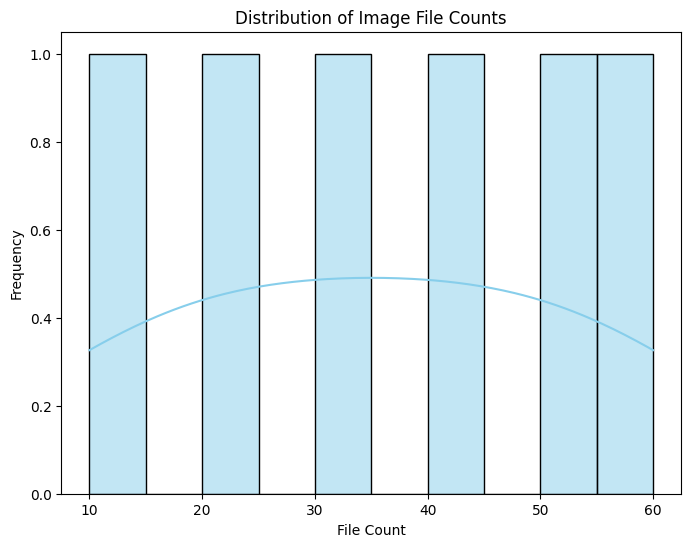

In [387]:
# Plot histogram
plt.figure(figsize=(8, 6))
sns.histplot(df['File Count'], bins=10, kde=True, color='skyblue')  # kde=True adds a smooth curve
plt.title('Distribution of Image File Counts')
plt.xlabel('File Count')
plt.ylabel('Frequency')
plt.show()

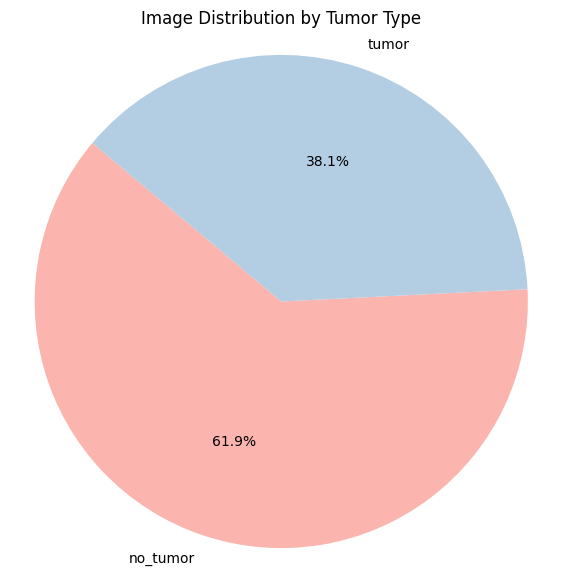

In [388]:
# Group by Subdirectory and sum File Count
grouped = df.groupby('Subdirectory')['File Count'].sum()

# Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(grouped, labels=grouped.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
plt.title('Image Distribution by Tumor Type')
plt.axis('equal')  # Equal aspect ratio ensures the pie is a circle
plt.show()

<ipython-input-389-a84f7d91ee98>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Subdirectory', y='File Count', palette='viridis')


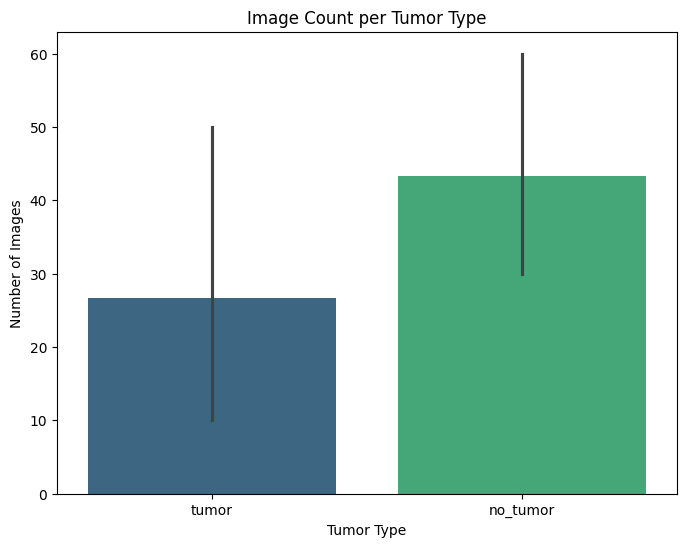

In [389]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Subdirectory', y='File Count', palette='viridis')
plt.title('Image Count per Tumor Type')
plt.xlabel('Tumor Type')
plt.ylabel('Number of Images')
plt.show()


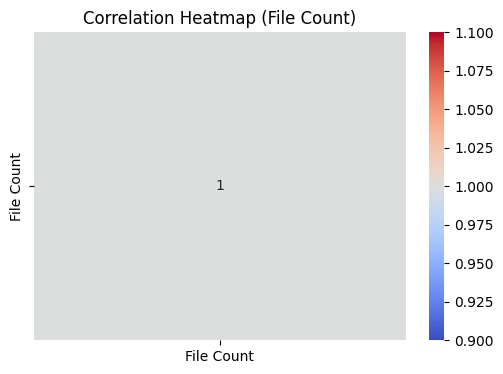

In [390]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['File Count']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (File Count)')
plt.show()



In [393]:
# Convert the 'Subdirectory' column to string type before encoding
df['Subdirectory'] = df['Subdirectory'].astype(str)

# Now apply Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['target'] = le.fit_transform(df['Subdirectory'])  # ya jo bhi target ho

In [394]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [395]:
print("Classes in y:", y.unique())


Classes in y: [1 0]


In [396]:
from sklearn.model_selection import train_test_split

# Check class distribution before splitting
print("Class distribution:", pd.Series(y).value_counts())

# If any class has less than 2 samples, don't stratify
if any(pd.Series(y).value_counts() < 2):
    print("Warning: Some classes have less than 2 samples. Stratification is disabled.")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # No stratification
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)  # Stratify

print("Train class distribution:", pd.Series(y_train).value_counts())
print("Test class distribution:", pd.Series(y_test).value_counts())

Class distribution: target
1    3
0    3
Name: count, dtype: int64
Train class distribution: target
0    2
1    2
Name: count, dtype: int64
Test class distribution: target
1    1
0    1
Name: count, dtype: int64


In [397]:
print(X.head())
print(X.describe())


   File Count  Description_Length
0          10                   5
1          20                  10
2          30                  15
3          40                  20
4          50                  25
       File Count  Description_Length
count    6.000000            6.000000
mean    35.000000           17.500000
std     18.708287            9.354143
min     10.000000            5.000000
25%     22.500000           11.250000
50%     35.000000           17.500000
75%     47.500000           23.750000
max     60.000000           30.000000


In [398]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Check class distribution
print("Class distribution:", pd.Series(y).value_counts())

# Ensure n_splits is at least 2 and not greater than the smallest class size
n_splits = max(2, min(5, pd.Series(y).value_counts().min()))  # Use minimum between 5 and the smallest class size, but at least 2

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Perform cross-validation using the StratifiedKFold object
scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
print("Cross-validated accuracy:", scores.mean())

Class distribution: target
1    3
0    3
Name: count, dtype: int64
Cross-validated accuracy: 0.6666666666666666


In [399]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42)

In [400]:
train_pred = model.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, train_pred))

Training Accuracy: 1.0


In [401]:
dt_pred = model.predict(X_test) # Replace dt_model with model
print("Decision Tree Testing Accuracy:", accuracy_score(y_test, dt_pred))
print("Decision Tree Classification Report:\n", classification_report(y_test, dt_pred))

Decision Tree Testing Accuracy: 0.5
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [402]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [403]:
train_pred = model.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, train_pred))


Training Accuracy: 1.0


In [404]:
rf_pred = model.predict(X_test) # Replace rf_model with model
print("Random Forest Testing Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest Classification Report:\n", classification_report(y_test, rf_pred))

Random Forest Testing Accuracy: 0.5
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [405]:
y_pred = model.predict(X_test)
print("y_test:", y_test[:10].values)
print("y_pred:", y_pred[:10])


y_test: [1 0]
y_pred: [1 1]


In [406]:
print("Predictions vs Actual:", list(zip(y_pred[:10], y_test.values[:10])))


Predictions vs Actual: [(np.int64(1), np.int64(1)), (np.int64(1), np.int64(0))]


In [407]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[0 1]
 [0 1]]


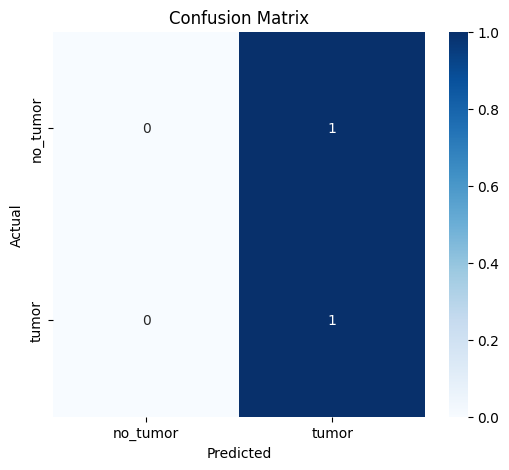

In [408]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['no_tumor', 'tumor'], yticklabels=['no_tumor', 'tumor'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [409]:
from sklearn.metrics import classification_report # Import the classification_report function

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
